## **BactHeCom**

In [26]:
import os
import warnings
import sqlite3
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [27]:
# paths
data_path="../data/"
db_path = f"{data_path}/db_bacthecom.db"
results_path = "../results/exploration"
os.makedirs(results_path, exist_ok=True)

# Load database

In [28]:
# Connect to the database
conn = sqlite3.connect(db_path)

# Create a cursor object
cursor = conn.cursor()

# Execute a query (example: list tables)
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print([x[0] for x in tables])

['sqlite_sequence', 'paciente', 'factores_riesgo_infeccion_bmr', 'antibiograma', 'semantic_mapping', 'episodio_infeccion', 'comorbilidad', 'signos_sintomas', 'episodio_ingreso']


In [29]:
df = {}
for tabname in tables:
    tabname = tabname[0]
    if tabname == 'sqlite_sequence' in tabname:
        continue
    else:
        df[tabname] = pd.read_sql_query(f"SELECT * FROM {tabname}", conn)

print(df.keys())  # show which tables were saved


dict_keys(['paciente', 'factores_riesgo_infeccion_bmr', 'antibiograma', 'semantic_mapping', 'episodio_infeccion', 'comorbilidad', 'signos_sintomas', 'episodio_ingreso'])


In [30]:
for key in df.keys():
    print(key)
    print(df[key].columns)
    print("\n")

paciente
Index(['record_id', 'sexo', 'fecha_nacimiento'], dtype='object')


factores_riesgo_infeccion_bmr
Index(['record_id', 'fecha_ingreso', 'hospit_ano_previo', 'hospit_mes_previo',
       'hospit_ano_previo_uci', 'hemodialisis_permanente',
       'dialisis_peritoneal', 'cateter_venoso', 'sonda_urinaria',
       'sonda_nasogastrica', 'derivacion_ventriculoper',
       'valvula_prot_cardiaca', 'portador_otros_disposit'],
      dtype='object')


antibiograma
Index(['episode_id', 'antimicrobiano', 'cmi', 'interpretacion'], dtype='object')


semantic_mapping
Index(['table_name', 'variable_name', 'description', 'uri'], dtype='object')


episodio_infeccion
Index(['episode_id', 'record_id', 'fecha_ingreso', 'fecha_cultivo',
       'area_hosp', 'id_cultivo', 'especimen', 'microorganismo',
       'fenotipo_resistencia'],
      dtype='object')


comorbilidad
Index(['record_id', 'fecha_ingreso', 'infarto', 'insuficiencia_cardiaca',
       'evp', 'e_cerebrovascular', 'demencia', 'e_pulmonar_cro

In [31]:
df['antibiograma']

,episode_id,antimicrobiano,cmi,interpretacion
0,1,Cefazolina,>16 mg/L,R
1,1,Trimetoprim,>4 mg/L,R
2,1,Ertapenem,>1 mg/L,R
3,1,Cefuroxima,>8 mg/L,R
4,1,Trimetroprim/sulfametoxazol,>4/76 mg/L,R
...,...,...,...,...
145147,6985,Imipenem,<=1 mg/L,S
145148,6985,Gentamicina,<=2 mg/L,S
145149,6985,Cefepime,<=1 mg/L,S
145150,6985,Ceftazidima,<=1 mg/L,S


## tbl_infecciones

In [32]:
tbl_inf = df['episodio_infeccion']
print(f"Number of infection episodes: {tbl_inf.shape[0]}")
print(f"Number of unique patients: {tbl_inf['record_id'].nunique()}")
tbl_inf.head()

Number of infection episodes: 6989
Number of unique patients: 3049


,episode_id,record_id,fecha_ingreso,fecha_cultivo,area_hosp,id_cultivo,especimen,microorganismo,fenotipo_resistencia
0,1,1,2021-08-24,2021-08-31,UCI,102007829,Sangre,Pseudomonas aeruginosa,None
1,2,2,2023-06-18,2023-06-30,General,103800271,Sangre,Escherichia coli,None
2,3,3,2022-02-11,2021-04-23,UCI,102901576,Secreción bronquial (aspirado),Klebsiella pneumoniae ssp pneumoniae,BLEE
3,4,3,2022-02-11,2021-04-23,UCI,102901576,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None
4,5,3,2022-02-11,2021-04-29,UCI,102901576,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None


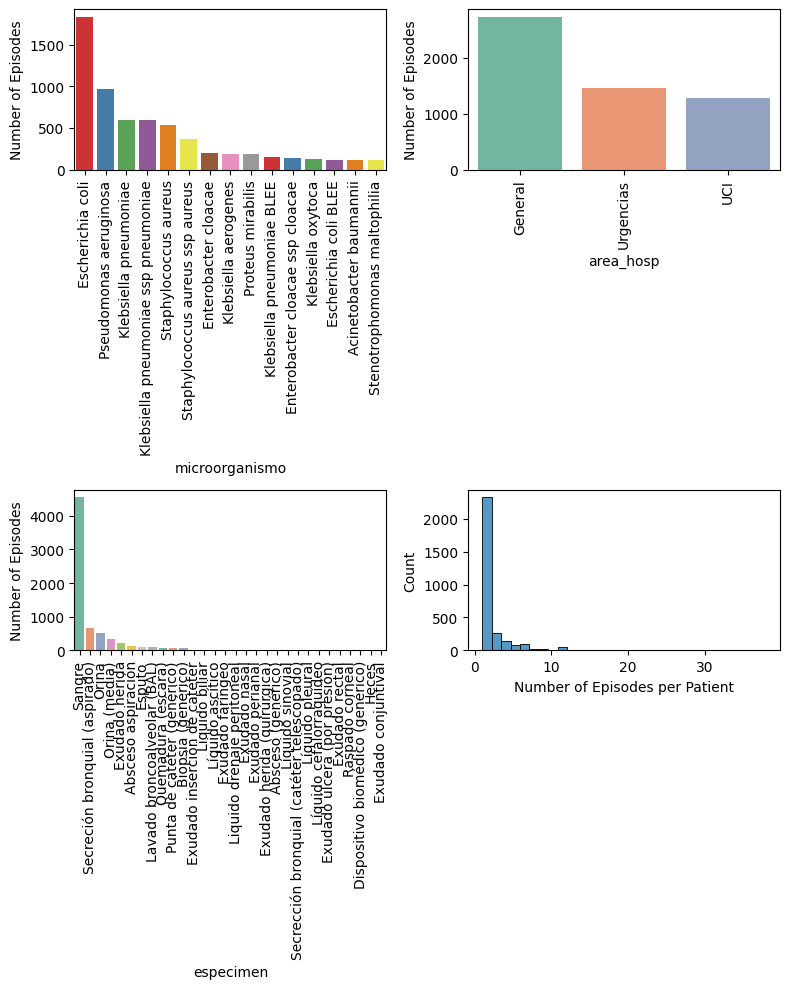

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(8, 10))

# 1. Top 10 microorganisms
counts = tbl_inf["microorganismo"].value_counts().reset_index()
counts.columns = ["microorganismo", "count"]
sns.barplot(
    data=counts.iloc[:15, :],
    x="microorganismo",
    y="count",
    palette="Set1",
    ax=ax[0, 0]
)
ax[0, 0].tick_params(axis='x', rotation=90)
ax[0, 0].set_ylabel('Number of Episodes')

# 2. Area hospital
areas = tbl_inf['area_hosp'].value_counts()
sns.barplot(x=areas.index, y=areas.values, palette="Set2", ax=ax[0, 1])
ax[0, 1].tick_params(axis='x', rotation=90)
ax[0, 1].set_ylabel('Number of Episodes')

# 3. Specimen type
especimen = tbl_inf["especimen"].value_counts()
sns.barplot(x=especimen.index, y=especimen.values, palette="Set2", ax=ax[1, 0])
ax[1, 0].tick_params(axis='x', rotation=90)
ax[1, 0].set_ylabel('Number of Episodes')
ax[1,0].set_title('')

# 4. Number of episodes per patient
num_episodes = tbl_inf.groupby('record_id').size()
sns.histplot(num_episodes, bins=30, kde=False, ax=ax[1, 1])
ax[1, 1].set_xlabel('Number of Episodes per Patient')
ax[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(results_path,'infection_episodes_summary.png'))

## tbl_ingreso

In [34]:
tbl_ingreso = df['episodio_ingreso']
tbl_ingreso.head()

,record_id,fecha_ingreso,fecha_alta,organo_aparato,foco_controlable,IRAs_nosocomial,mortalidad,uci_por_el_episodio,duracion_UCI,mujer_gestante,codigo_postal,paciente_residencia
0,1,2021-08-24,2021-09-09,None,NaN,Si,1,1,14,0,4007,0.0
1,2,2023-06-18,2023-07-13,None,NaN,Si,0,1,3,0,4740,0.0
2,3,2022-02-11,2022-04-06,Infeccion de cateter vascular,1.0,Si,0,1,24,0,4700,NaN
3,4,2021-05-15,2021-07-28,None,NaN,Si,0,1,42,0,18800,0.0
4,5,2021-07-04,2022-01-04,Infeccion tracto respiratorio inferior,0.0,Si,0,1,78,0,23009,0.0


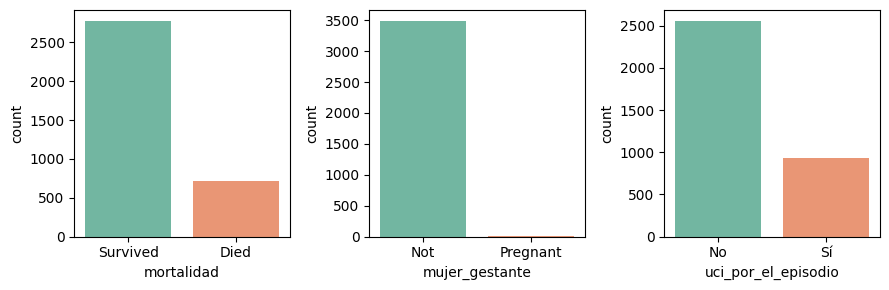

In [35]:
# mortalidad
fig, ax = plt.subplots(1,3,figsize=(9, 3))

sns.barplot(tbl_ingreso['mortalidad'].value_counts(), ax=ax[0], palette="Set2")
ax[0].set_xticklabels(['Survived', 'Died'])

sns.barplot(tbl_ingreso['mujer_gestante'].value_counts(), ax=ax[1], palette="Set2")
ax[1].set_xticklabels(['Not', 'Pregnant'])

# ingreso UCI o no
sns.barplot(tbl_ingreso['uci_por_el_episodio'].value_counts(), ax=ax[2], palette="Set2")
ax[2].set_xticklabels(['No','Sí'])

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'ingreso_summary.png'), dpi=300)

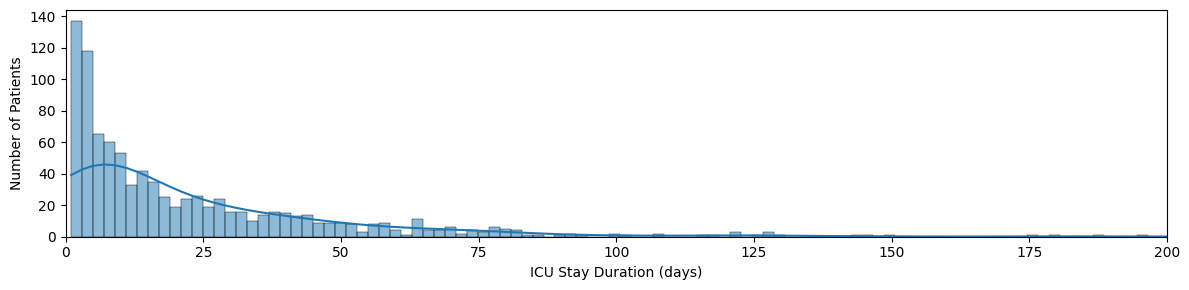

In [36]:
# Duration of ICU stay
fig, ax = plt.subplots(figsize=(12, 3))

# Filter >0 and compute counts
uci_ingreso = tbl_ingreso['duracion_UCI'][tbl_ingreso['duracion_UCI'] > 0] # remove those episodes that did not go to ICU

# Plot as barplot
sns.histplot(data=uci_ingreso, bins=200, kde=True)

ax.set_xlabel('ICU Stay Duration (days)')
ax.set_ylabel('Number of Patients')
ax.set_xlim(0, 200)

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'duracion_UCI.png'), dpi=300)
plt.show()


## tbl_paciente

In [37]:
tbl_paciente=df['paciente']
tbl_paciente["edad"] = (pd.to_datetime("today").normalize() - pd.to_datetime(tbl_paciente['fecha_nacimiento'])).dt.days // 365
tbl_paciente.head()

,record_id,sexo,fecha_nacimiento,edad
0,1,Hombre,1943-03-28,82
1,2,Mujer,1959-12-16,65
2,3,Hombre,1976-11-14,49
3,4,Hombre,1992-09-27,33
4,5,Mujer,1994-07-13,31


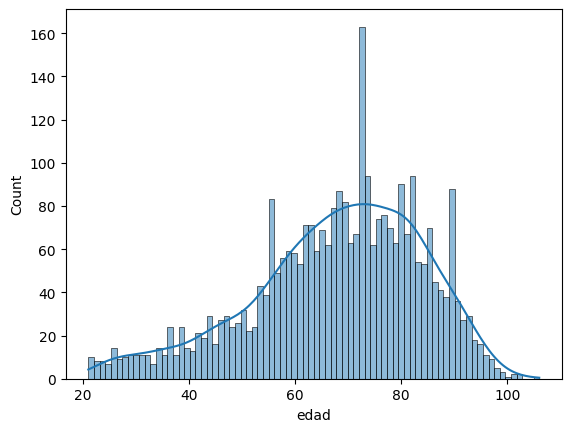

In [38]:
sns.histplot(tbl_paciente['edad'], bins=80, kde=True)
plt.savefig(os.path.join(results_path, 'edad_pacientes.png'), dpi=300)

## tbl_riesgos

In [39]:
tbl_riesgos = df['factores_riesgo_infeccion_bmr']
tbl_riesgos.head()

,record_id,fecha_ingreso,hospit_ano_previo,hospit_mes_previo,hospit_ano_previo_uci,hemodialisis_permanente,dialisis_peritoneal,cateter_venoso,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit
0,1,2021-08-24,0,0,0,0,0,0,0,1,0,0,0
1,2,2023-06-18,0,0,0,0,0,0,0,1,0,0,0
2,3,2022-02-11,1,0,1,0,0,0,0,1,0,0,0
3,4,2021-05-15,0,0,0,0,0,0,0,1,0,0,0
4,5,2021-07-04,0,0,0,0,0,0,0,0,0,0,0


In [40]:
tbl_riesgos.iloc[:,2:].sum().sort_values(ascending=False)

hospit_ano_previo           1648
hospit_mes_previo            661
hemodialisis_permanente      362
sonda_urinaria               314
sonda_nasogastrica           236
hospit_ano_previo_uci        226
dialisis_peritoneal          199
valvula_prot_cardiaca         32
derivacion_ventriculoper      32
cateter_venoso                24
portador_otros_disposit       18
dtype: int64

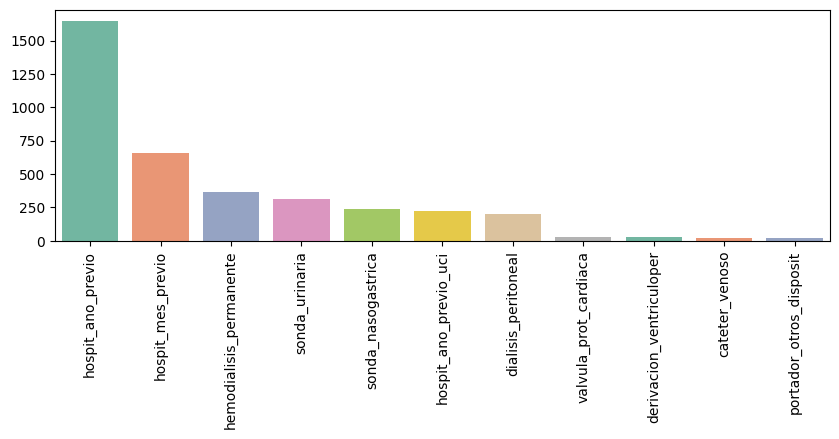

In [41]:
fig,ax=plt.subplots(figsize=(10,3))
sns.barplot(tbl_riesgos.iloc[:,2:].sum().sort_values(ascending=False), ax=ax, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.savefig(os.path.join(results_path, 'factores_riesgo.png'), dpi=300)


## tbl_comorbilidades

In [42]:
df.keys()

dict_keys(['paciente', 'factores_riesgo_infeccion_bmr', 'antibiograma', 'semantic_mapping', 'episodio_infeccion', 'comorbilidad', 'signos_sintomas', 'episodio_ingreso'])

In [43]:
tbl_comorb = df['comorbilidad']
tbl_comorb.columns

Index(['record_id', 'fecha_ingreso', 'infarto', 'insuficiencia_cardiaca',
       'evp', 'e_cerebrovascular', 'demencia', 'e_pulmonar_cronica',
       'ulcera_peptica', 'colagenopatia', 'hemiplejia', 'erc',
       'neoplasia_tratamiento_activo', 'neoplasia_solida_metastasica',
       'neoplasia_solida_no_metastasica', 'tipo_cancer', 'linfoma', 'leucemia',
       'sida', 'puntaje_child_pugh', 'hepatopatia_ligera',
       'hepatopatia_moderada_o_grave', 'tipo_hepatopatia', 'diabetes',
       'diabetes_sin_lesion_organo_diana', 'diabetes_con_lesion_organo_diana',
       'inmunosupresion', 'causa_inmunosupresion', 'fecha_TOS', 'TOS',
       'fecha_TPH', 'TPH', 'clasificacion_quemadura', 'gran_quemado'],
      dtype='object')

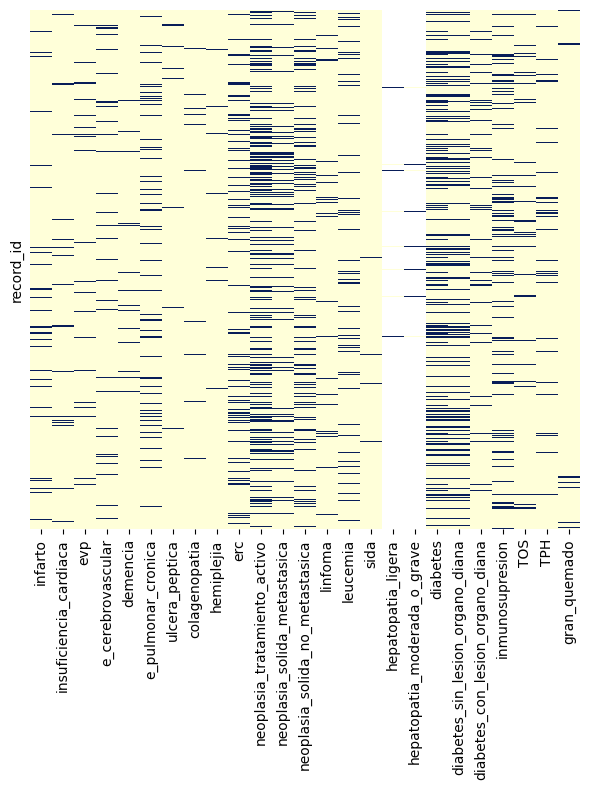

In [44]:
# Select only numeric columns
heat_comorb = tbl_comorb.drop(columns=['record_id']).select_dtypes(include=[np.number])
# Optional: set index to 'record_id' if it exists
if 'record_id' in tbl_comorb.columns:
    heat_comorb = heat_comorb.set_index(tbl_comorb['record_id'])

# Plot heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(heat_comorb, cbar=False, cmap="YlGnBu", yticklabels='')
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'heatmap_comorbilidades.png'), dpi=300)

## tbl_sepsis

In [45]:
tbl_sepsis = df['signos_sintomas']
tbl_sepsis.head()

,record_id,fecha_ingreso,foco,sepsis,shock_septico,qsofa,somnolencia_estupor_coma,situacion_funcional_basal,indice_de_charlson,escala_karnofsky,...,lesiones_piel,lesiones_mucosas,cefalea,dolores_articulares,temperatura,frec_cardiaca,frecuencia_respiratoria,tension_arterial_sist,tension_arterial_diast,saturacion_pO2
0,1,2021-08-24,None,1,1,0,None,None,11,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023-06-18,None,0,0,0,None,None,4,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2022-02-11,cateter venoso,0,0,0,None,None,2,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2021-05-15,None,1,1,0,None,Necesita ayuda importante y asistencia médica ...,0,50.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2021-07-04,pulmonar,0,0,0,None,"Normal, sin quejas ni evidencia de enfermedad",2,100.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


# ProfileReport

In [46]:
merged_df = pd.merge(tbl_inf, tbl_ingreso, on=['record_id','fecha_ingreso'])
merged_df = pd.merge(merged_df, tbl_paciente, on='record_id')
merged_df = pd.merge(merged_df, tbl_comorb, on=['record_id','fecha_ingreso'])
merged_df = pd.merge(merged_df, tbl_riesgos, on=['record_id','fecha_ingreso'])
merged_df = pd.merge(merged_df, tbl_sepsis, on=['record_id','fecha_ingreso'])
merged_df.set_index('record_id', inplace=True)
merged_df.head()

,episode_id,fecha_ingreso,fecha_cultivo,area_hosp,id_cultivo,especimen,microorganismo,fenotipo_resistencia,fecha_alta,organo_aparato,...,lesiones_piel,lesiones_mucosas,cefalea,dolores_articulares,temperatura,frec_cardiaca,frecuencia_respiratoria,tension_arterial_sist,tension_arterial_diast,saturacion_pO2
record_id,,,,,,,,,,,,,,,,,,,,,
1,1,2021-08-24,2021-08-31,UCI,102007829,Sangre,Pseudomonas aeruginosa,None,2021-09-09,None,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023-06-18,2023-06-30,General,103800271,Sangre,Escherichia coli,None,2023-07-13,None,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2022-02-11,2021-04-23,UCI,102901576,Secreción bronquial (aspirado),Klebsiella pneumoniae ssp pneumoniae,BLEE,2022-04-06,Infeccion de cateter vascular,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2022-02-11,2021-04-23,UCI,102901576,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None,2022-04-06,Infeccion de cateter vascular,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,5,2022-02-11,2021-04-29,UCI,102901576,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None,2022-04-06,Infeccion de cateter vascular,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
merged_df.to_csv(os.path.join(data_path, 'merged_bacthecom.csv'))

In [ ]:
# create report
profile = ProfileReport(merged_df, title="Bacthecom Data Report", explorative=True)
profile.to_notebook_iframe()
profile.to_file(os.path.join(results_path, "bacthecom_data_report.html"))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 96/96 [00:00<00:00, 328.22it/s]
